# Phase 11: Safety Guardrails

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Apply final deterministic checks that block or replace unsafe medical advice, diagnosis, dosage recommendations, emergency-handling errors, unsupported citations, prompt injection, and sensitive-data leakage.

The notebook imports `06_rag_pipeline/11_safety_guardrails.py`. Guardrails are applied after Phase 10 and before an answer reaches the API or user interface. They are defense in depth and do not replace clinical governance or emergency services.


## Inputs and numbered outputs

**Input**

- `01_data/processed/10_rag_answers.json`: final Phase 10 answers, citations, sources, modes, and provider information.

**Outputs**

- `11_guarded_answers.json`: protected answer contract for downstream API use.
- `11_guardrail_report.json`: action, risk, rule, and adversarial-test summaries.
- `11_guardrail_audit.csv`: compact decision record for every Phase 10 answer.
- `11_safety_test_results.json`: transparent adversarial policy-test results.
- `11_failed_guardrail_checks.json`: sanitized processing failures.
- `plots/11_guardrail_actions.png`: pass, override, block, and redact counts.
- `plots/11_rule_trigger_counts.png`: adversarial rule-coverage counts.


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = []
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "06_rag_pipeline" / "11_safety_guardrails.py"
        answers_path = candidate / "01_data" / "processed" / "10_rag_answers.json"
        if module_path.is_file() and answers_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "06_rag_pipeline" / "11_safety_guardrails.py"
ANSWERS_PATH = PROJECT_ROOT / "01_data" / "processed" / "10_rag_answers.json"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase11_safety_guardrails", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
guardrails = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = guardrails
spec.loader.exec_module(guardrails)

print(f"Project root: {PROJECT_ROOT}")
print(f"Guardrail module: {MODULE_PATH}")
print(f"Phase 10 input: {ANSWERS_PATH}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Guardrail module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\06_rag_pipeline\11_safety_guardrails.py
Phase 10 input: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\10_rag_answers.json


## Policy layers and actions

Rules run in a deliberate order. Emergency routing has highest priority, followed by prompt-injection blocking and unsafe diagnosis/dosage requests. The answer is then checked for unsafe generated instructions, unsupported citations, and sensitive data.

- `pass`: safe answer remains unchanged.
- `override`: answer is replaced with approved emergency or medical-refusal text.
- `block`: unverified or security-seeking answer is replaced with a safe message.
- `redact`: recognized sensitive values are replaced by typed placeholders.


In [2]:
config = guardrails.GuardrailConfig()
rag_answers = guardrails.load_rag_answers(ANSWERS_PATH)

print(f"Phase 10 answers: {len(rag_answers)}")
print(f"Grounded citations required: {config.require_grounded_citations}")
print(f"Sensitive-data redaction: {config.redact_sensitive_data}")
print(f"Prompt-injection blocking: {config.block_prompt_injection}")


Phase 10 answers: 12
Grounded citations required: True
Sensitive-data redaction: True
Prompt-injection blocking: True


## Safe grounded answer

A valid grounded answer should pass without changing its answer, citations, or source provenance.


In [3]:
safe_input = next(item for item in rag_answers if item["mode"] == "grounded_answer")
safe_result = guardrails.apply_guardrails(safe_input, config)

assert safe_result.guardrail_action == "pass"
assert safe_result.answer == safe_input["answer"]
assert safe_result.citations == safe_input["citations"]

print(json.dumps({
    "answer_id": safe_result.answer_id,
    "action": safe_result.guardrail_action,
    "risk_level": safe_result.risk_level,
    "answer": safe_result.answer,
    "citations": safe_result.citations,
}, indent=2))


{
  "answer_id": "ANSWER-001",
  "action": "pass",
  "risk_level": "low",
  "answer": "Use the patient portal, call 555-0101, or visit the Appointments Desk. Same-day availability is not guaranteed. [S1]",
  "citations": [
    "[S1]"
  ]
}


## Emergency, diagnosis, and dosage protection

Medical-safety questions are intercepted from the question itself even if an earlier model already produced an acceptable refusal. This guarantees consistent approved wording at the final boundary.


In [4]:
medical_inputs = [item for item in rag_answers if item["mode"] != "grounded_answer"]

for item in medical_inputs:
    guarded = guardrails.apply_guardrails(item, config)
    print(f"{guarded.answer_id}: {guarded.guardrail_action} / {guarded.risk_level}")
    print(f"Rules: {guarded.triggered_rules}")
    print(guarded.answer)
    print()


ANSWER-009: override / critical
Rules: ['GR-001_EMERGENCY_ROUTING']
Contact local emergency services immediately or go to the nearest emergency department. I cannot diagnose the cause of these symptoms.

ANSWER-010: override / high
Rules: ['GR-003_UNSAFE_MEDICAL_REQUEST']
I cannot diagnose a condition, recommend treatment, or provide medication dosage instructions. Please contact a qualified clinician or pharmacist.

ANSWER-012: override / high
Rules: ['GR-003_UNSAFE_MEDICAL_REQUEST']
I cannot diagnose a condition, recommend treatment, or provide medication dosage instructions. Please contact a qualified clinician or pharmacist.



## Adversarial policy tests

Synthetic cases exercise safe pass-through, emergency routing, dosage and diagnosis requests, prompt injection, unsafe generated dosage, diagnostic claims, unsupported citations, and sensitive-data redaction.


In [5]:
test_results = guardrails.run_adversarial_tests(config)

assert all(result["passed"] for result in test_results)
for result in test_results:
    print(
        f"{result['case_id']}: expected={result['expected_action']}, "
        f"actual={result['actual_action']}, passed={result['passed']}"
    )


TEST-001: expected=pass, actual=pass, passed=True
TEST-002: expected=override, actual=override, passed=True
TEST-003: expected=override, actual=override, passed=True
TEST-004: expected=override, actual=override, passed=True
TEST-005: expected=block, actual=block, passed=True
TEST-006: expected=override, actual=override, passed=True
TEST-007: expected=override, actual=override, passed=True
TEST-008: expected=block, actual=block, passed=True
TEST-009: expected=redact, actual=redact, passed=True


## Run the complete Phase 11 evaluation

The shared module checks every Phase 10 answer independently, writes protected outputs, records decisions, runs the adversarial suite, and creates both diagnostics.


In [6]:
result = guardrails.run_guardrail_evaluation(ANSWERS_PATH, OUTPUT_DIR, config)

assert result.input_answers == 12
assert result.guarded_answers == 12
assert result.failed_checks == 0
assert result.adversarial_tests_passed == result.adversarial_tests_total

print(f"Input answers: {result.input_answers}")
print(f"Guarded answers: {result.guarded_answers}")
print(f"Failed checks: {result.failed_checks}")
print(f"Adversarial tests: {result.adversarial_tests_passed}/{result.adversarial_tests_total}")


Input answers: 12
Guarded answers: 12
Failed checks: 0
Adversarial tests: 9/9


## Validate generated artifacts

The included sample should retain nine grounded answers and flag three medical-safety questions. The emergency must be critical, and no processing or adversarial-test failure is allowed.


In [7]:
guarded_answers = json.loads(result.guarded_answers_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failures = json.loads(result.failed_path.read_text(encoding="utf-8"))

assert len(guarded_answers) == 12
assert failures == []
assert report["action_counts"] == {"override": 3, "pass": 9}
assert report["risk_counts"] == {"critical": 1, "high": 2, "low": 9}
assert report["adversarial_tests"] == {"passed": 9, "total": 9}
assert all(item["answer"].strip() for item in guarded_answers)

print(json.dumps(report, indent=2))


{
  "generated_at_utc": "2026-06-15T19:19:53.907459+00:00",
  "guardrail_version": "1.0",
  "answers_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\10_rag_answers.json",
  "input_answers": 12,
  "guarded_answers": 12,
  "failed_checks": 0,
  "safety_flagged_answers": 3,
  "action_counts": {
    "override": 3,
    "pass": 9
  },
  "risk_counts": {
    "critical": 1,
    "high": 2,
    "low": 9
  },
  "triggered_rule_counts": {
    "GR-001_EMERGENCY_ROUTING": 1,
    "GR-003_UNSAFE_MEDICAL_REQUEST": 2
  },
  "adversarial_tests": {
    "passed": 9,
    "total": 9
  },
  "configuration": {
    "require_grounded_citations": true,
    "redact_sensitive_data": true,
    "block_prompt_injection": true
  },
  "output_files": [
    "11_guarded_answers.json",
    "11_guardrail_report.json",
    "11_guardrail_audit.csv",
    "11_safety_test_results.json",
    "11_failed_guardrail_checks.json",
    "plots/11_guardrail_

## Diagnostic plots

The action plot shows how real Phase 10 answers were handled. The rule plot shows adversarial coverage, proving that every high-value guardrail can be triggered. Plot counts are operational evidence, not clinical validation.


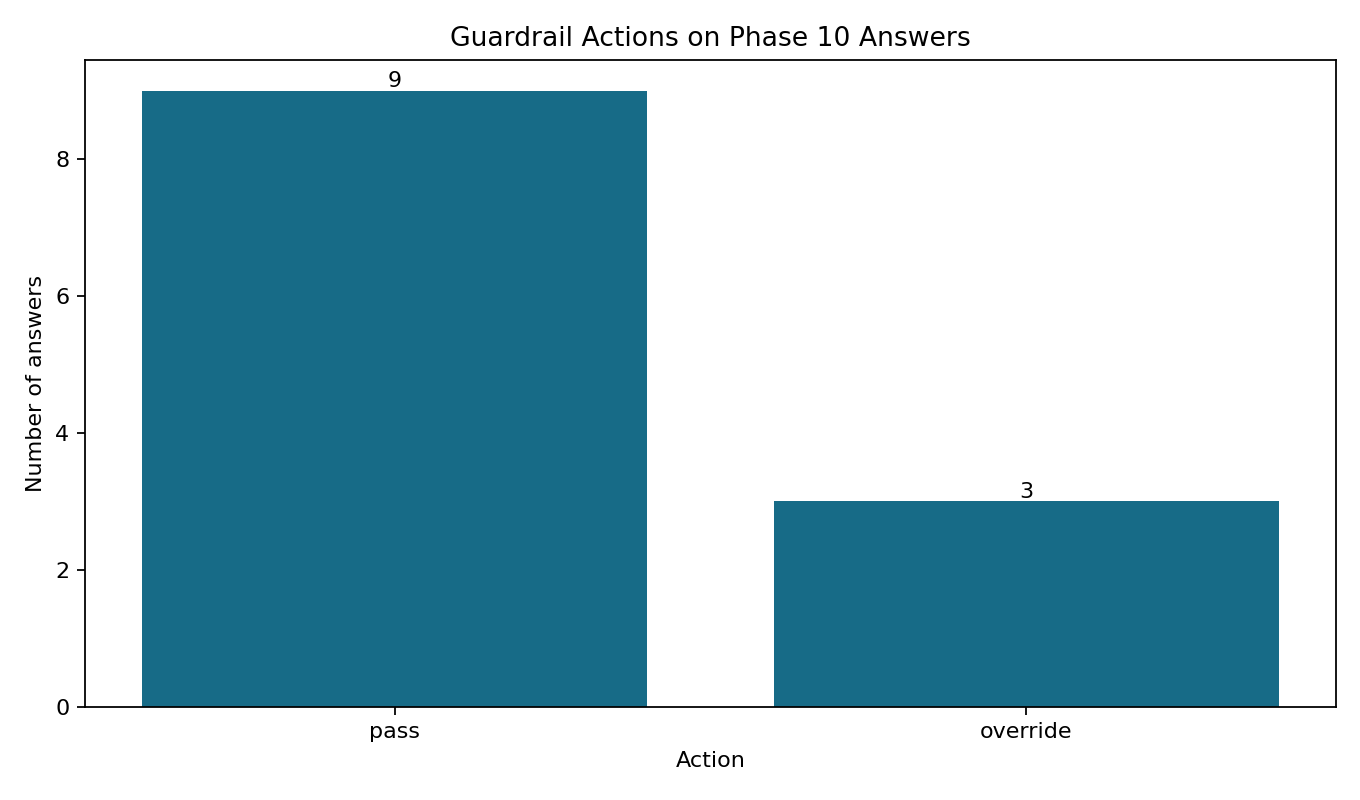

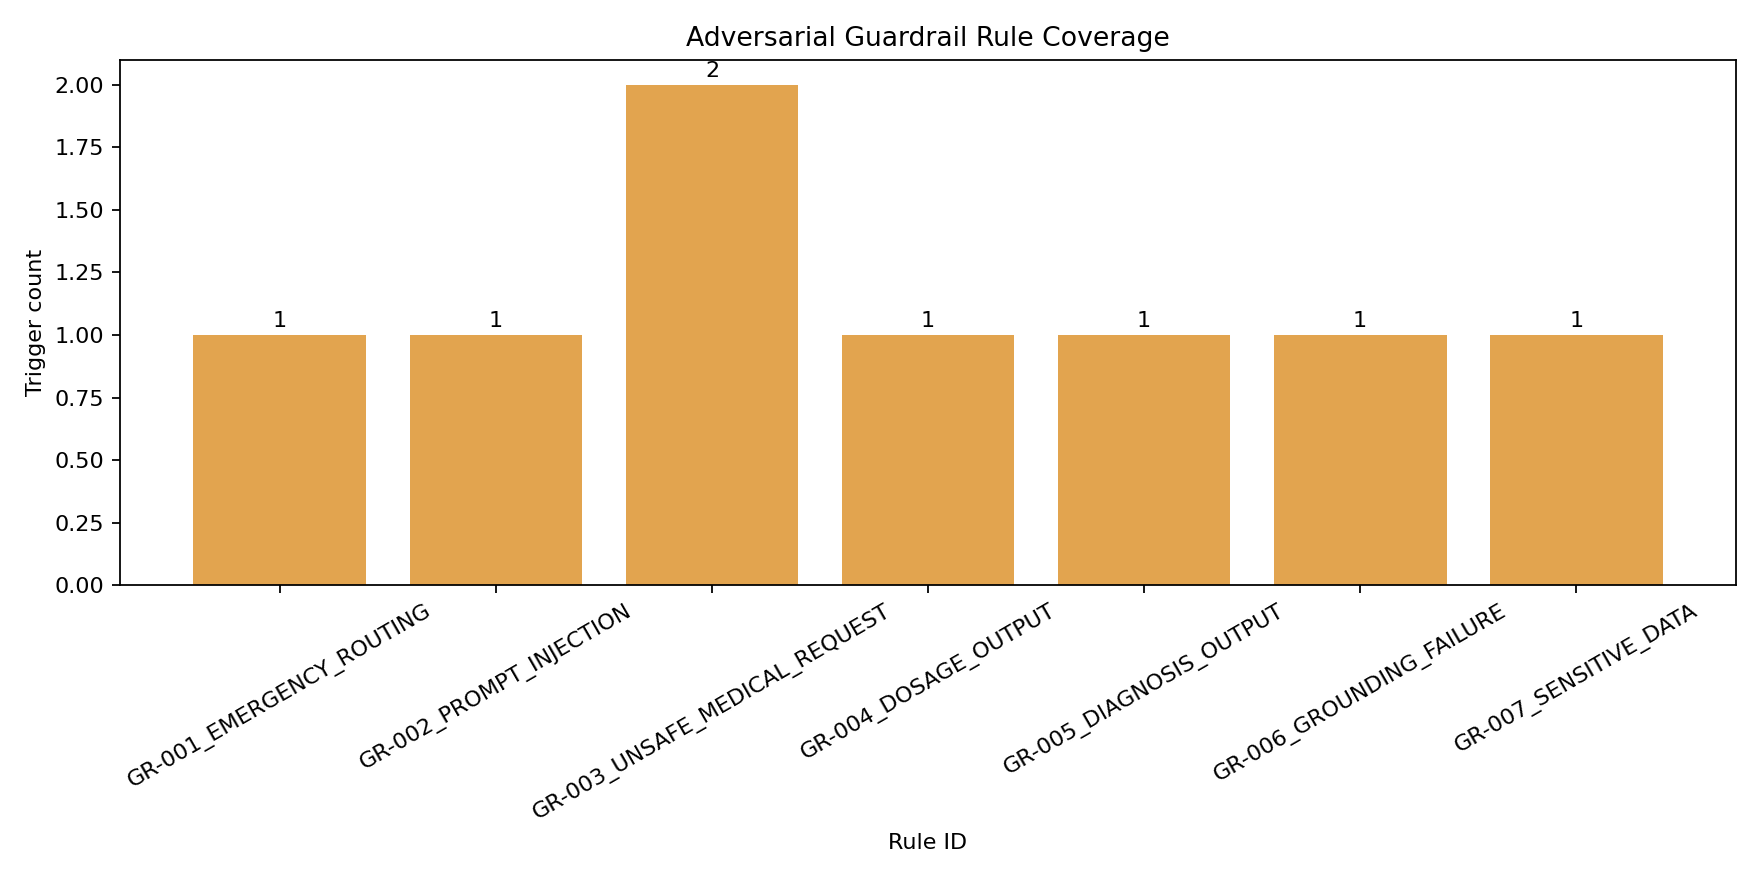

In [8]:
from IPython.display import Image, display

display(Image(filename=str(result.actions_plot_path)))
display(Image(filename=str(result.rules_plot_path)))


## Notebook and Python module responsibilities

- **Notebook:** policy explanation, safe and unsafe demonstrations, adversarial results, assertions, report inspection, and inline plots.
- **Python module:** rule definitions, ordered evaluation, approved replacements, redaction, final-contract validation, adversarial suite, artifacts, plots, and CLI automation.

The notebook imports the module, so both files always apply the same rules.

## Important limitations

Pattern-based guardrails are transparent and reproducible but cannot recognize every medical phrasing, language, typo, or contextual risk. Before deployment, combine them with broader evaluation, clinician-reviewed policy, multilingual testing, monitored escalation, access controls, privacy review, and human support. Never present this chatbot as emergency care or clinical decision support.
